** Assignment 4: End-to-End NLP Pipeline for Semantic Search**

In [2]:

##  1. Install & Import Libraries

!pip install nltk spacy scikit-learn gensim datasets matplotlib seaborn

import nltk
import spacy
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec
from datasets import load_dataset

In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
# 2. Load Dataset (HuggingFace)
dataset = load_dataset("imdb", split="train[:2000]")  # sample for speed
df = pd.DataFrame(dataset)

texts = df['text'].tolist()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [5]:
## 📌 3. Text Cleaning

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)   # remove HTML
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()
    return text

cleaned_texts = [clean_text(t) for t in texts]

In [6]:
# 4. Tokenization + Stopword Removal
stop_words = set(stopwords.words('english'))

def tokenize(text):
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

tokenized_texts = [tokenize(t) for t in cleaned_texts]

In [8]:
## 5. Lemmatization (SpaCy)
nlp = spacy.load("en_core_web_sm")

def lemmatize(tokens):
    doc = nlp(" ".join(tokens))
    return [token.lemma_ for token in doc]

lemmatized_texts = [lemmatize(tokens) for tokens in tokenized_texts]

In [9]:
## 6. Vocabulary Creation

vocab = set(word for doc in lemmatized_texts for word in doc)
print("Vocabulary Size:", len(vocab))

Vocabulary Size: 24572


In [10]:
## 7. Bag of Words (BoW)

corpus = [" ".join(doc) for doc in lemmatized_texts]

bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(corpus)

print("BoW Shape:", bow_matrix.shape)

BoW Shape: (2000, 24549)


In [11]:
## 8. TF-IDF Vectors

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

print("TF-IDF Shape:", tfidf_matrix.shape)

TF-IDF Shape: (2000, 24549)


In [12]:
##  9. Word Embeddings (Word2Vec)
w2v_model = Word2Vec(sentences=lemmatized_texts,
                    vector_size=100,
                    window=5,
                    min_count=2,
                    workers=4)

In [13]:
# Example
print(w2v_model.wv.most_similar("good"))

[('thing', 0.9909307360649109), ('funny', 0.9893308281898499), ('much', 0.9875969290733337), ('act', 0.986858069896698), ('anything', 0.9865986108779907), ('mean', 0.9864711165428162), ('though', 0.9854264259338379), ('worth', 0.9850144982337952), ('really', 0.9847913980484009), ('feel', 0.9835131168365479)]


In [14]:
##  10. Sentence Embeddings (Average Word Vectors)

def sentence_vector(tokens):
    vectors = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
    if len(vectors) == 0:
        return np.zeros(100)
    return np.mean(vectors, axis=0)

sentence_vectors = np.array([sentence_vector(doc) for doc in lemmatized_texts])

In [15]:
## 11. Similarity Search

def find_similar(query, top_n=5):
    query_clean = clean_text(query)
    query_tokens = tokenize(query_clean)
    query_lemmas = lemmatize(query_tokens)
    query_vec = sentence_vector(query_lemmas).reshape(1, -1)

    similarities = cosine_similarity(query_vec, sentence_vectors)[0]
    top_indices = similarities.argsort()[-top_n:][::-1]

    return [(texts[i], similarities[i]) for i in top_indices]

# Example
results = find_similar("This movie was fantastic and exciting")
for r in results:
    print(r)

("This movie is about as underrated as Police Acadmey Mission to Moscow. This movie is never funny. It's maybe the worst comedy spoof ever made. Very boring,and dumb beyond belief. For those people that think this movie is underrated god help you. I give this movie * out of ****<br /><br />", np.float32(0.998656))
("The only saving grace of this movie is that it serves as the 0 end of the movie rating scale. Now if I see a movie that really stinks I say this movie was a real Pecker. I believe this movie is a perfect example of Christina Ricci's one dimensional acting. Horrible", np.float32(0.9985839))
("I've just lost 2 hours of my life watching this mindless plot. I could make a better movie with my cellphone camera. How do they manage to get actors to play in those movies?? Porn movies have better scenarios and effects... I wish I had those 2 hours back...<br /><br />The only good thing about this movie is the cast. Even though, their acting skills in this one could not lift this mov

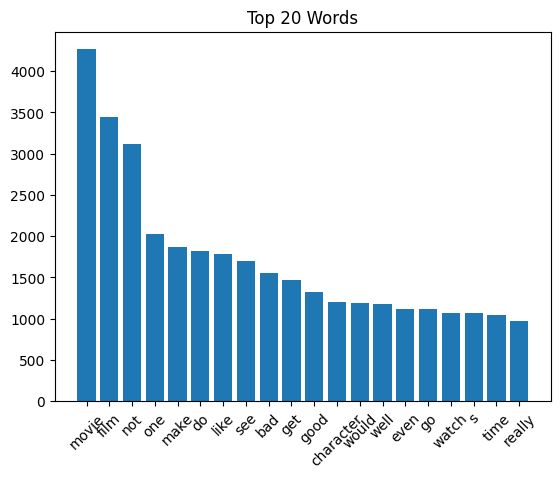

In [16]:
## 12. Insights & Visualization

###  Word Frequency Plot


from collections import Counter

all_words = [word for doc in lemmatized_texts for word in doc]
word_freq = Counter(all_words).most_common(20)

words, counts = zip(*word_freq)

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Words")
plt.show()



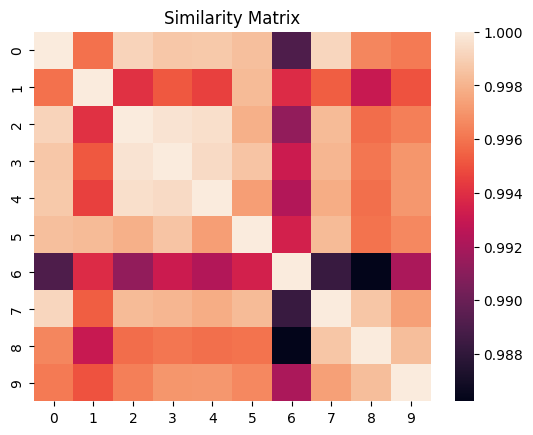

In [17]:
###  Similarity Heatmap (Sample)


sample_sim = cosine_similarity(sentence_vectors[:10])

plt.figure()
sns.heatmap(sample_sim)
plt.title("Similarity Matrix")
plt.show()


#  Final Pipeline Summary

| Step             | Description                     |
| ---------------- | ------------------------------- |
| Cleaning         | Remove noise, HTML, punctuation |
| Tokenization     | Split text into words           |
| Stopwords        | Remove common words             |
| Lemmatization    | Normalize words                 |
| Vocabulary       | Unique words set                |
| BoW / TF-IDF     | Text → numerical vectors        |
| Word2Vec         | Semantic word embeddings        |
| Sentence Vectors | Average embeddings              |
| Similarity       | Cosine similarity search        |
| Visualization    | Insights from data              |